In [3]:
# 1) 한 번만: 압축 풀기
!tar xzf EnglishFnt.tgz -C sample_data/

In [4]:
# ────────────────────────────────────────────────────────────────
# 0) EnglishFnt에서 D/N/E 데이터셋 자동 구축
# ────────────────────────────────────────────────────────────────
import os
from pathlib import Path
from PIL import Image
import shutil
import random

# 원본 폰트 이미지 경로
FNT_BASE = Path("sample_data/English/Fnt")
OUT_BASE = Path("dataset")
CLASS_MAP = {'Sample014': 'D', 'Sample024': 'N', 'Sample015': 'E'}

# dataset/D, dataset/N, dataset/E 폴더 생성 및 초기화
for c in ['D', 'N', 'E']:
    d = OUT_BASE / c
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

# 클래스별로 파일 복사 (최대 2000장씩 샘플)
for sample, label in CLASS_MAP.items():
    src = FNT_BASE / sample
    dst = OUT_BASE / label
    files = list(src.glob("*.png"))
    random.shuffle(files)
    for i, f in enumerate(files[:2000]):
        img = Image.open(f).convert("L").resize((32,32))
        img.save(dst / f"{label}_{i:04d}.png")

print("EnglishFnt → dataset/D,N,E 자동 구축 완료")

# ────────────────────────────────────────────────────────────────
# 1) Keras 데이터셋 로드 및 증강
# ────────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE    = (32, 32)
BATCH_SIZE  = 64
EPOCHS      = 30
TFLITE_PATH = "dne_classifier.tflite"
CLASS_NAMES = ["D", "N", "E"]
VALID_SPLIT = 0.2
SEED        = 42

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=VALID_SPLIT,
    subset="training",
    seed=SEED
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=VALID_SPLIT,
    subset="validation",
    seed=SEED
)

normalization = layers.Rescaling(1.0 / 255)
data_augmentation = tf.keras.Sequential([
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.3),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomFlip("horizontal"),
])


def preprocess_train(x, y):
    x = tf.expand_dims(x, -1) if x.shape[-1] != 1 else x
    x = data_augmentation(x)
    x = normalization(x)
    return x, y

train_ds = train_ds.map(preprocess_train).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)

# ────────────────────────────────────────────────────────────────
# 2) CNN 모델 정의 및 학습
# ────────────────────────────────────────────────────────────────
def build_dne_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

model = build_dne_model(IMG_SIZE + (1,), len(CLASS_NAMES))
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# ────────────────────────────────────────────────────────────────
# 3) TFLite 변환 및 저장
# ────────────────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)
print(f"3-class TFLite model saved at '{TFLITE_PATH}'")


EnglishFnt → dataset/D,N,E 자동 구축 완료
Found 3048 files belonging to 3 classes.
Using 2439 files for training.
Found 3048 files belonging to 3 classes.
Using 609 files for validation.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             

 Total params: 157,027 (613.39 KB)

 Trainable params: 156,387 (610.89 KB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 18s 173ms/step - accuracy: 0.4472 - loss: 1.0610 - val_accuracy: 0.3383 - val_loss: 1.1161
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6984 - loss: 0.7283 - val_accuracy: 0.3727 - val_loss: 1.0888
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8232 - loss: 0.4946 - val_accuracy: 0.3448 - val_loss: 0.9981
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8563 - loss: 0.3798 - val_accuracy: 0.4680 - val_loss: 1.1468
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8916 - loss: 0.2947 - val_accuracy: 0.5057 - val_loss: 0.9500
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9144 - loss: 0.2739 - val_accuracy: 0.5090 - val_loss: 0.8764
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9284 - loss: 0.1984 - val_accuracy: 0.8079 - val_loss: 0.5468
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9143 - loss: 0.2392 - val_accuracy: 0.5484 -

In [11]:
# ─────────────────────────────
# 0. 패키지 임포트 및 설정
# ─────────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
import tensorflow as tf

# 사용자 설정
IMAGE_PATH   = "/content/test_2.png"       # 근무표 이미지 경로
TFLITE_MODEL = "dne_classifier.tflite"      # TFLite 분류기 모델
WHITE_THRESH = 0.92                       # 빈 셀 판단 기준
CLASS_LABELS = ['D', 'N', 'E']              # 분류 클래스
HEADER_SKIP_Y = 1                           # 위쪽 헤더 행 수
HEADER_SKIP_X = 1                           # 왼쪽 헤더 열 수
# 회전 재시도 트리거 범위 (max_prob)
LOW_CONF_MIN = 0.2
LOW_CONF_MAX = 0.4

# ─────────────────────────────
# 1. 표 검출 및 워핑(정렬) - 개선 버전
# ─────────────────────────────
def detect_and_warp_table(img_path):
    orig_img = cv2.imread(img_path)
    assert orig_img is not None, f"Image not found at {img_path}"

    # [NEW] 얇은 선이 뭉개지지 않도록 INTER_CUBIC으로 확대
    target_height = 400
    h, w = orig_img.shape[:2]
    scale = target_height / h
    orig_img = cv2.resize(orig_img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    gray = cv2.cvtColor(orig_img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    binary = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 8)
    plt.imshow(binary, cmap='gray')
    plt.title("이진화된 이미지")
    plt.axis('off')
    plt.show()

    # 외곽 검출
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    table_contour = None
    for cnt in contours:
        approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)
        if len(approx) == 4:
            table_contour = approx
            break

    if table_contour is not None:
        def sort_points(pts):
            pts = pts.reshape(4, 2)
            s = pts.sum(axis=1)
            diff = np.diff(pts, axis=1)
            return np.array([
                pts[np.argmin(s)], pts[np.argmin(diff)],
                pts[np.argmax(s)], pts[np.argmax(diff)]
            ], dtype='float32')
        rect = sort_points(table_contour)
        width = int(max(np.linalg.norm(rect[0] - rect[1]), np.linalg.norm(rect[2] - rect[3])))
        height = int(max(np.linalg.norm(rect[0] - rect[3]), np.linalg.norm(rect[1] - rect[2])))
        dst = np.array([[0,0],[width-1,0],[width-1,height-1],[0,height-1]], dtype='float32')
        M = cv2.getPerspectiveTransform(rect, dst)
        warped = cv2.warpPerspective(orig_img, M, (width, height))
        temp = orig_img.copy()
        cv2.drawContours(temp, [table_contour], -1, (0, 255, 0), 3)
    else:
        print("⚠️ 표 외곽 인식 실패 — 원본 사용")
        warped = orig_img
        temp = orig_img.copy()

    # 회전 보정
    h, w = warped.shape[:2]
    if h > w:
        warped = cv2.rotate(warped, cv2.ROTATE_90_CLOCKWISE)

    temp_rgb = cv2.cvtColor(temp, cv2.COLOR_BGR2RGB)
    plt.imshow(temp_rgb)
    plt.title("표 외곽 검출 결과")
    plt.axis('off')
    plt.show()
    return warped


# ─────────────────────────────
# 2. 표 내부 셀 라인 검출 및 분할 (강화 버전)
# ─────────────────────────────
def get_table_cells(warped, skip_rows=HEADER_SKIP_Y, skip_cols=HEADER_SKIP_X,
                    header_pos="top-left", try_polarity=True):
    img = warped
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape)==3 else img.copy()

    # ---------- (NEW) 대비 강화 ----------
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    # ---------- 1) 이진화 ----------
    bw = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY_INV, 21, 10)

    # ---------- (NEW) 얇은 선 보강 ----------
    bw = cv2.dilate(bw, cv2.getStructuringElement(cv2.MORPH_RECT, (2,2)), 1)

    # ---------- 2) 텍스트 억제 + 라인 추출 ----------
    def suppress_text_and_extract_lines(binary):
        h, w = binary.shape
        num, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
        text_mask = np.zeros_like(binary)
        area_max = int(0.01 * w * h)
        for i in range(1, num):
            x, y, ww, hh, area = stats[i]
            if area < 10:
                continue
            ar = ww / (hh + 1e-6)
            if area <= area_max and 0.2 <= ar <= 5.0:
                text_mask[y:y+hh, x:x+ww] = 255
        no_text = cv2.bitwise_and(binary, cv2.bitwise_not(text_mask))

        # 선 추출용 커널 (조금 더 작게 조정)
        hor_k = cv2.getStructuringElement(cv2.MORPH_RECT, (max(15, w//25), 1))
        ver_k = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(15, h//25)))
        hor_only = cv2.morphologyEx(no_text, cv2.MORPH_OPEN, hor_k)
        ver_only = cv2.morphologyEx(no_text, cv2.MORPH_OPEN, ver_k)

        # 선 굵기 복원
        hor_only = cv2.dilate(hor_only, cv2.getStructuringElement(cv2.MORPH_RECT,(3,1)), 1)
        ver_only = cv2.dilate(ver_only, cv2.getStructuringElement(cv2.MORPH_RECT,(1,3)), 1)

        # 감도 완화
        row_len = (hor_only > 0).sum(axis=1)
        col_len = (ver_only > 0).sum(axis=0)
        row_min = int(0.35 * w)
        col_min = int(0.35 * h)

        y_idxs = np.where(row_len >= row_min)[0].tolist()
        x_idxs = np.where(col_len >= col_min)[0].tolist()

        def group(coords, tol=15):
            if not coords: return []
            coords = sorted(coords)
            out, cur = [], [coords[0]]
            for c in coords[1:]:
                if c - cur[-1] <= tol: cur.append(c)
                else: out.append(int(np.mean(cur))); cur=[c]
            out.append(int(np.mean(cur)))
            return out

        y_lines = group(y_idxs)
        x_lines = group(x_idxs)

        grid = cv2.bitwise_or(hor_only, ver_only)
        grid = cv2.dilate(grid, cv2.getStructuringElement(cv2.MORPH_RECT, (2,2)), 1)
        return y_lines, x_lines, grid

    # ---------- 3) 라인 검출 ----------
    y_lines, x_lines, grid = suppress_text_and_extract_lines(bw)

    # 극성 반전 재시도
    if try_polarity and (len(y_lines) < 3 or len(x_lines) < 3):
        y_lines, x_lines, grid = suppress_text_and_extract_lines(255 - bw)

    # ---------- 4) 폴백 ----------
    if len(y_lines) < 3 or len(x_lines) < 3:
        def fallback_detect(binary):
            h, w = binary.shape
            hor_k = cv2.getStructuringElement(cv2.MORPH_RECT, (max(15, w//25), 1))
            ver_k = cv2.getStructuringElement(cv2.MORPH_RECT, (1, max(15, h//25)))
            hor = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, hor_k)
            ver = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, ver_k)
            ys = np.where((hor>0).sum(axis=1) > w*0.25)[0].tolist()
            xs = np.where((ver>0).sum(axis=0) > h*0.25)[0].tolist()
            return ys, xs, cv2.bitwise_or(hor, ver)
        y_lines, x_lines, grid = fallback_detect(bw)

    if len(y_lines) < 3 or len(x_lines) < 3:
        raise RuntimeError("격자 라인을 충분히 찾지 못했습니다. 커널/임계값 조정 필요")

    # ---------- 5) 헤더 스킵 ----------
    if header_pos == "top-left":
        data_ys = y_lines[skip_rows:]
        data_xs = x_lines[skip_cols:]
    elif header_pos == "bottom-right":
        data_ys = y_lines[:-skip_rows] if skip_rows>0 else y_lines
        data_xs = x_lines[:-skip_cols] if skip_cols>0 else x_lines
    else:
        data_ys, data_xs = y_lines, x_lines

    row_ranges = [(data_ys[i], data_ys[i+1]) for i in range(len(data_ys)-1)]
    col_ranges = [(data_xs[j], data_xs[j+1]) for j in range(len(data_xs)-1)]

    # ---------- 6) 시각화 ----------
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    H, W = vis.shape[:2]
    for y in y_lines: cv2.line(vis, (0, y), (W-1, y), (255, 0, 0), 1)
    for x in x_lines: cv2.line(vis, (x, 0), (x, H-1), (255, 0, 0), 1)
    plt.imshow(vis)
    plt.title("grid 검출 결과 (강화된 라인 처리)")
    plt.axis('off')
    plt.show()

    return gray, row_ranges, col_ranges

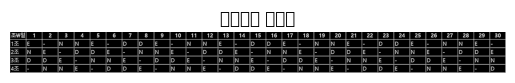

⚠️ 표 외곽 인식 실패 — 원본 사용


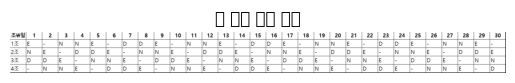

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


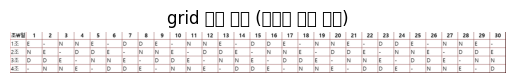

Blank cell detected by white_ratio: 0.9208984375
Blank cell detected by white_ratio: 0.9599609375
Blank cell detected by white_ratio: 0.9912109375
Blank cell detected by white_ratio: 0.9375
Blank cell detected by white_ratio: 0.94921875
Blank cell detected by white_ratio: 0.9599609375
Blank cell detected by white_ratio: 0.9912109375
Blank cell detected by white_ratio: 0.9462890625
Blank cell detected by white_ratio: 0.9453125
Blank cell detected by white_ratio: 0.9599609375
Blank cell detected by white_ratio: 0.9912109375
Blank cell detected by white_ratio: 0.9482421875
Blank cell detected by white_ratio: 0.9375
Blank cell detected by white_ratio: 0.9599609375
Blank cell detected by white_ratio: 0.9912109375
Blank cell detected by white_ratio: 0.9462890625
Blank cell detected by white_ratio: 0.947265625
Blank cell detected by white_ratio: 0.9599609375
Blank cell detected by white_ratio: 0.9912109375
Blank cell detected by white_ratio: 0.9375


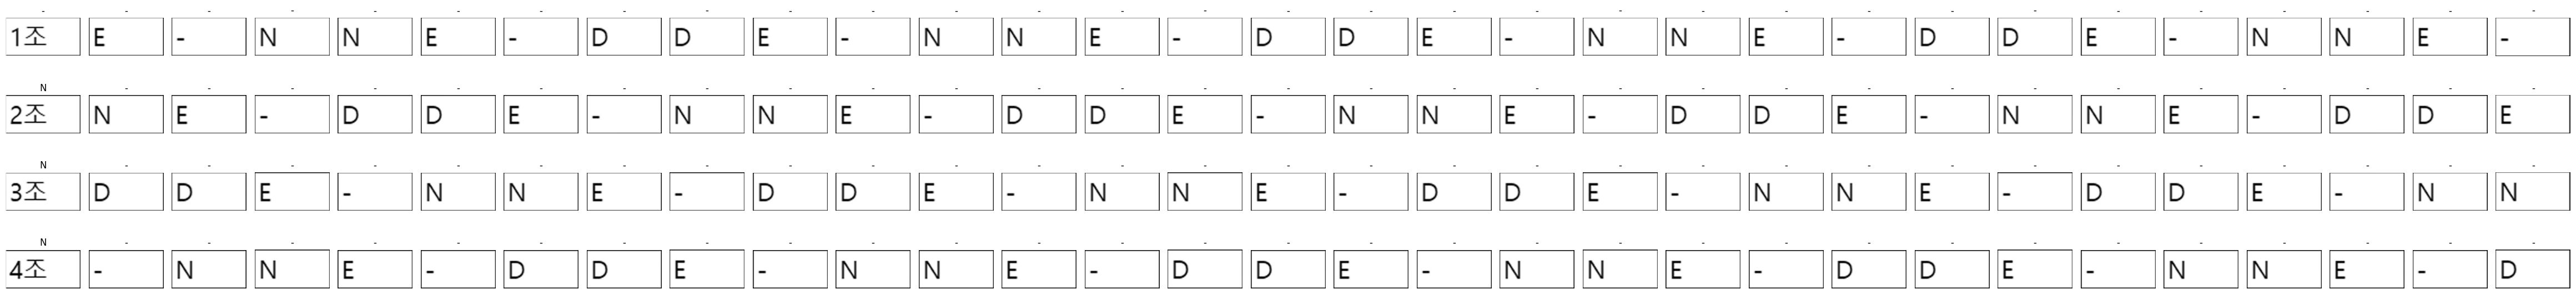

✅ schedule_inferred4.json 저장 완료
{
  "1": {
    "1": "N",
    "2": "-",
    "3": "-",
    "4": "-",
    "5": "-",
    "6": "-",
    "7": "-",
    "8": "-",
    "9": "-",
    "10": "-",
    "11": "-",
    "12": "-",
    "13": "-",
    "14": "-",
    "15": "-",
    "16": "-",
    "17": "-",
    "18": "-",
    "19": "-",
    "20": "-",
    "21": "-",
    "22": "-",
    "23": "-",
    "24": "-",
    "25": "-",
    "26": "-",
    "27": "-",
    "28": "-",
    "29": "-",
    "30": "-",
    "31": "-"
  },
  "2": {
    "1": "N",
    "2": "-",
    "3": "-",
    "4": "-",
    "5": "-",
    "6": "-",
    "7": "-",
    "8": "-",
    "9": "-",
    "10": "-",
    "11": "-",
    "12": "-",
    "13": "-",
    "14": "-",
    "15": "-",
    "16": "-",
    "17": "-",
    "18": "-",
    "19": "-",
    "20": "-",
    "21": "-",
    "22": "-",
    "23": "-",
    "24": "-",
    "25": "-",
    "26": "-",
    "27": "-",
    "28": "-",
    "29": "-",
    "30": "-",
    "31": "-"
  },
  "3": {
    "1": "N",
    "

In [12]:

# ─────────────────────────────
# 3. tight crop + OCR 분류 함수(기존과 동일)
# ─────────────────────────────
def tight_crop_and_resize(cell_img, out_size=(32,32), extra_crop=3):
    if cell_img is None or cell_img.size == 0:
        return np.full(out_size, 255, dtype=np.uint8)
    _, threshed = cv2.threshold(cell_img, 200, 255, cv2.THRESH_BINARY)
    inv = 255 - threshed
    coords = cv2.findNonZero(inv)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        x1 = max(x + extra_crop, 0)
        y1 = max(y + extra_crop, 0)
        x2 = min(x + w - extra_crop, cell_img.shape[1])
        y2 = min(y + h - extra_crop, cell_img.shape[0])
        if x2 > x1 and y2 > y1:
            cropped = cell_img[y1:y2, x1:x2]
        else:
            cropped = cell_img[y:y+h, x:x+w]
    else:
        cropped = cell_img
    resized = cv2.resize(cropped, out_size)
    return resized

def classify_dne(cell_img, interpreter, input_details, output_details, debug=False, r=0, c=0):
    tight_img = tight_crop_and_resize(cell_img)
    white_ratio = np.mean(tight_img > 180)
    if debug:
        cv2.imwrite(f'debug_cell_r{r}_c{c}.png', tight_img)

    # 완전 공백 → 분류 대상 제외
    if white_ratio > WHITE_THRESH:
        if debug: print("Blank cell detected by white_ratio:", white_ratio)
        return '-', 1.0, True   # (label, max_prob, is_blank)

    h, w = input_details[0]['shape'][1:3]
    inp = tight_img.astype(np.float32) / 255.0
    sample = inp.reshape(1, h, w, 1)
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    out = interpreter.get_tensor(output_details[0]['index'])[0]
    max_prob = float(np.max(out))

    if debug:
        print(f"Probabilities: D={out[0]:.3f}, N={out[1]:.3f}, E={out[2]:.3f} (max={max_prob:.3f})")

    # 저신뢰는 공백 취급
    if max_prob < 0.5:
        if debug: print("Blank cell detected by prob:", max_prob)
        return '-', max_prob, True

    label = CLASS_LABELS[int(np.argmax(out))]
    return label, max_prob, False
# ─────────────────────────────
# 새로 추가: 1패스(그리드 추출 + 분류) 실행을 함수로 분리
# ─────────────────────────────
# ===== 자동 스킵 기준(blank 기반) =====
DROP_COL0_BLANK_FRAC = 0.60   # 1열 blank 비율 ≥ 이 값 → 열 삭제
DROP_ROW0_BLANK_FRAC = 0.80   # 1행 blank 비율 ≥ 이 값 → 행 삭제
PROB_THR = 0.80               # (옵션) 확률 보조 기준 유지하고 싶으면 사용

def run_pass(warped, interpreter, input_details, output_details, show_cells=True, header_pos="top-left"):
    # 1) 그리드 재검출 (헤더 스킵 X)
    gray, data_rows, data_cols = get_table_cells(
        warped, skip_rows=0, skip_cols=0, header_pos=header_pos
    )

    n_rows, n_cols = len(data_rows), len(data_cols)
    probs  = np.zeros((n_rows, n_cols), dtype=np.float32)
    labels = [['' for _ in range(n_cols)] for _ in range(n_rows)]
    blanks = np.zeros((n_rows, n_cols), dtype=bool)

    result = {}
    low_conf_found = False
    debug_count = 0

    if show_cells:
        plt.figure(figsize=(n_cols*1.5, n_rows*1.5))

    # 2) 전 셀 분류 + 결과 저장
    low_conf_count = 0
    for r, (y1, y2) in enumerate(data_rows):
        for c, (x1, x2) in enumerate(data_cols):
            cell_img = gray[y1:y2, x1:x2]
            debug = (debug_count < 20)
            label, max_prob, is_blank = classify_dne(
                cell_img, interpreter, input_details, output_details,
                debug=debug, r=r, c=c
            )
            labels[r][c] = label
            probs[r, c]  = max_prob
            blanks[r, c] = is_blank

            if LOW_CONF_MIN <= max_prob <= LOW_CONF_MAX:
                low_conf_count += 1

            if show_cells:
                ax = plt.subplot(n_rows, n_cols, r*n_cols + c + 1)
                plt.imshow(cell_img, cmap='gray'); plt.title(label); plt.axis('off')

            if debug: debug_count += 1

    if show_cells:
        plt.tight_layout(); plt.show()

    # 3) 1열/1행 자동 스킵 판단 (blank 기반)
    drop_col0 = False
    drop_row0 = False

    if n_cols >= 1:
        # 1열 blank 비율(= is_blank 또는 라벨 '-')
        frac_blank_col0 = np.mean(blanks[:, 0] | (np.array([labels[r][0] for r in range(n_rows)]) == '-'))
        # 보조: 확률도 낮은 비율
        # frac_lowprob_col0 = np.mean(probs[:, 0] < PROB_THR)
        if frac_blank_col0 >= DROP_COL0_BLANK_FRAC:
            drop_col0 = True

    if n_rows >= 1:
        cols_idx = range(1, n_cols) if drop_col0 else range(n_cols)
        cols_idx = list(cols_idx)
        if len(cols_idx) > 0:
            row0_blanks = [blanks[0, c] or (labels[0][c] == '-') for c in cols_idx]
            frac_blank_row0 = np.mean(row0_blanks)
            # 보조: 확률 낮은 비율
            # frac_lowprob_row0 = np.mean(probs[0, cols_idx] < PROB_THR)
            if frac_blank_row0 >= DROP_ROW0_BLANK_FRAC:
                drop_row0 = True

    # 4) 결과 생성(스킵 적용)
    start_r = 1 if drop_row0 else 0
    start_c = 1 if drop_col0 else 0

    for r in range(start_r, n_rows):
        row_dict = {}
        out_c = 1
        for c in range(start_c, n_cols):
            row_dict[str(out_c)] = labels[r][c]
            out_c += 1
        result[str(r - start_r + 1)] = row_dict

    return result, low_conf_count


# ─────────────────────────────
# 4. 메인 실행 (셀 분할+OCR+시각화)
# ─────────────────────────────
def main():
    # (1) 표 워핑
    warped = detect_and_warp_table(IMAGE_PATH)

    # (2) 모델 준비 (모델은 재사용 가능)
    interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL)
    interpreter.allocate_tensors()
    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # (3) 1차 패스: 현재 warped로 "처음부터" 실행
    result, low_conf_count = run_pass(
        warped, interpreter, input_details, output_details, show_cells=True
    )

    # (4) 저신뢰(0.2~0.6) 셀이 하나라도 있으면 → warped를 180° 회전
    #     그리고 '이전 상태를 전혀 쓰지 않고' 다시 그리드부터 새로 실행
    if low_conf_count >= 5:
        print(f"⟲ 저신뢰 셀이 {low_conf_count}개 → 180° 회전 후 완전 재실행")
        warped_rot = cv2.rotate(warped, cv2.ROTATE_180)
        plt.close('all')

        result, _ = run_pass(
            warped_rot, interpreter, input_details, output_details, show_cells=True
        )

    # (5) 결과 저장
    with open("schedule_inferred4.json", "w", encoding="utf-8") as f:
        json.dump(result, f, ensure_ascii=False, indent=2)
    print("✅ schedule_inferred4.json 저장 완료")
    print(json.dumps(result, ensure_ascii=False, indent=2))



# ─────────────────────────────
# 5. 실행
# ─────────────────────────────
if __name__ == '__main__':
    main()
